In [1]:
import os
import pandas as pd
import janitor
import json
from tqdm.notebook import tqdm
from tableone import TableOne

import warnings

warnings.filterwarnings("ignore")
from typing import Callable, List, Tuple, Optional
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
from matplotlib.patches import Patch

In [3]:
df_pypi_gh_mapping = pd.read_csv("../data/pypi_github_mapping.csv")
repo_names = set(df_pypi_gh_mapping["repo_full_name"])
print(f"Packages with GitHub repos: {len(df_pypi_gh_mapping)}")
print(f"Treated: {df_pypi_gh_mapping['treatment'].sum()}")
df_pypi_gh_mapping

Packages with GitHub repos: 23965
Treated: 4823


,file_project,github_url,repo_full_name,treatment
0,0-orchestrator,https://github.com/g8os/grid,g8os/grid,0
1,0rest,https://github.com/0oio/0rest,0oio/0rest,1
2,0x01-autocert-dns-aliyun,https://github.com/Smart-Hypercube/autocert,Smart-Hypercube/autocert,0
3,0x01-cubic-sdk,https://github.com/Smart-Hypercube/cubic-sdk,Smart-Hypercube/cubic-sdk,0
4,101703087-topsis,https://github.com/user/101703087-topsis,user/101703087-topsis,0
...,...,...,...,...
23960,zzip,NaN,NaN,0
23961,zzx-deep-genome,NaN,NaN,0
23962,zzz,https://github.com/oddshocks/zzz,oddshocks/zzz,0
23963,zzz233,https://github.com/husisy/zzz233,husisy/zzz233,0


In [4]:
df_pypi_gh_mapping["has_github"] = df_pypi_gh_mapping["repo_full_name"].notna()
df_pypi_gh_mapping.groupby("treatment")["has_github"].agg(["sum", "count", "mean"])

,sum,count,mean
treatment,,,
0,14241,19142,0.743966
1,3631,4823,0.752851


In [5]:
GH_ARCHIVE_PATH = "../data/gharchive/"
months = sorted([f for f in os.listdir(GH_ARCHIVE_PATH) if f.endswith(".parquet")])
# months

RELEVANT_TYPES = {
    "ForkEvent",
    "WatchEvent",
    "IssuesEvent",
    "PushEvent",
    "PullRequestEvent",
    "ReleaseEvent",
}

dfs = []
for fname in tqdm(months):
    df = pd.read_parquet(
        os.path.join(GH_ARCHIVE_PATH, fname),
        columns=["created_at", "type", "repo_id", "repo_name", "payload"],
    )
    df = df[df["repo_name"].isin(repo_names) & df["type"].isin(RELEVANT_TYPES)]
    dfs.append(df)
    print(f"{fname}: {len(df)} events")

df_events = pd.concat(dfs, ignore_index=True)
df_events["created_at"] = pd.to_datetime(df_events["created_at"], utc=True)
print(
    f"\nTotal: {len(df_events)} events across {df_events['repo_name'].nunique()} repos"
)

  0%|          | 0/12 [00:00<?, ?it/s]

gh_events_2023-01.parquet: 164493 events
gh_events_2023-02.parquet: 167902 events
gh_events_2023-03.parquet: 192395 events
gh_events_2023-04.parquet: 251514 events
gh_events_2023-05.parquet: 208540 events
gh_events_2023-06.parquet: 167106 events
gh_events_2023-07.parquet: 157251 events
gh_events_2023-08.parquet: 159967 events
gh_events_2023-09.parquet: 150455 events
gh_events_2023-10.parquet: 160321 events
gh_events_2023-11.parquet: 148423 events
gh_events_2023-12.parquet: 121149 events

Total: 2049516 events across 9289 repos


In [6]:
def get_issues_action(payload):
    try:
        p = payload if isinstance(payload, dict) else json.loads(payload)
        return p.get("action")
    except:
        return None


df_events = df_events.assign(
    issues_action=lambda df_: (
        df_.loc[df_["type"] == "IssuesEvent", "payload"].apply(get_issues_action)
    )
)
df_events.query("type=='IssuesEvent'").head(20)

,created_at,type,repo_id,repo_name,payload,issues_action
1,2023-01-01 03:23:54+00:00,IssuesEvent,100655296,jyotisham/jyotisha,"{""action"":""opened"",""issue"":{""url"":""https://api...",opened
9,2023-01-04 17:42:30+00:00,IssuesEvent,15337142,micropython/micropython,"{""action"":""opened"",""issue"":{""url"":""https://api...",opened
13,2023-01-04 12:07:49+00:00,IssuesEvent,575355038,dream-faster/krisi,"{""action"":""opened"",""issue"":{""url"":""https://api...",opened
31,2023-01-26 12:41:29+00:00,IssuesEvent,442864346,lcompilers/lpython,"{""action"":""opened"",""issue"":{""url"":""https://api...",opened
37,2023-01-10 22:59:22+00:00,IssuesEvent,31211061,galaxyproject/galaxy,"{""action"":""opened"",""issue"":{""url"":""https://api...",opened
38,2023-01-10 11:52:05+00:00,IssuesEvent,401275197,elementary-data/elementary,"{""action"":""closed"",""issue"":{""url"":""https://api...",closed
41,2023-01-27 14:04:28+00:00,IssuesEvent,349547047,xsuite/xsuite,"{""action"":""opened"",""issue"":{""url"":""https://api...",opened
56,2023-01-05 17:30:08+00:00,IssuesEvent,412599271,os-climate/physrisk,"{""action"":""opened"",""issue"":{""url"":""https://api...",opened
71,2023-01-05 17:09:24+00:00,IssuesEvent,336009292,equinor/fmu-dataio,"{""action"":""opened"",""issue"":{""url"":""https://api...",opened
72,2023-01-05 18:08:59+00:00,IssuesEvent,133072277,opencybersecurityalliance/stix-shifter,"{""action"":""opened"",""issue"":{""url"":""https://api...",opened


In [7]:
TREATMENT_START = pd.Timestamp("2023-06-03", tz="UTC")
TREATMENT_END = pd.Timestamp("2023-06-09", tz="UTC")

df_pre = df_events[df_events["created_at"] < TREATMENT_START]
df_treat = df_events[
    (df_events["created_at"] >= TREATMENT_START)
    & (df_events["created_at"] < TREATMENT_END)
]
df_post = df_events[df_events["created_at"] >= TREATMENT_END]

In [8]:
def agg_period(df, suffix):
    counts = (
        df[df["type"] != "IssuesEvent"]
        .groupby(["repo_name", "type"])
        .size()
        .unstack(fill_value=0)
    )

    issues = df[df["type"] == "IssuesEvent"]
    counts["issues_opened"] = (
        issues[issues["issues_action"] == "opened"].groupby("repo_name").size()
    )
    counts["issues_closed"] = (
        issues[issues["issues_action"] == "closed"].groupby("repo_name").size()
    )

    counts = counts.fillna(0).astype(int)
    counts.columns = [f"{c.lower()}_{suffix}" for c in counts.columns]
    return counts


pre_counts = agg_period(df_pre, "pre")
treat_counts = agg_period(df_treat, "treat")
post_counts = agg_period(df_post, "post")

In [9]:
df_all = (
    df_pypi_gh_mapping.select_columns(["file_project", "repo_full_name", "treatment"])
    .set_index("repo_full_name")
    .join(pre_counts)
    .join(treat_counts)
    .join(post_counts)
    .fillna(0)
    .pipe(
        lambda df_: df_.astype({c: "int64" for c in df_.columns if c != "file_project"})
    )
    .clean_names()
    .reset_index()
)
print(df_all.shape)
df_all.head()

(23965, 24)


,repo_full_name,file_project,treatment,forkevent_pre,pullrequestevent_pre,pushevent_pre,releaseevent_pre,watchevent_pre,issues_opened_pre,issues_closed_pre,...,watchevent_treat,issues_opened_treat,issues_closed_treat,forkevent_post,pullrequestevent_post,pushevent_post,releaseevent_post,watchevent_post,issues_opened_post,issues_closed_post
0,00-team/black-knight,black-knight,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,007gzs/sqltool,sqltool,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,00labs/huma-signals,huma-signals,0,7,197,220,0,6,2,0,...,0,0,0,1,49,40,0,0,0,0
3,00sapo/pycarla,pycarla,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,017RAFIRAMDHANI/PYTHON,latest-news,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [10]:
df_all.to_csv("../data/pypi_gharchive_events.csv", index=False)

In [11]:
pre_vars = [
    "watchevent_pre",
    "pushevent_pre",
    "pullrequestevent_pre",
    "issues_opened_pre",
    "issues_closed_pre",
    "forkevent_pre",
    "releaseevent_pre",
]

t1 = TableOne(
    df_all,
    columns=pre_vars,
    categorical=[],
    groupby="treatment",
    pval=True,
    htest_name=True,
)
t1

Grouped by treatment                                                                  
                                              Missing       Overall             0             1 P-Value            Test
n                                                             23965         19142          4823                        
watchevent_pre, mean (SD)                           0  18.2 (513.6)  18.2 (563.9)  18.1 (221.4)   0.979  Welch’s T-test
pushevent_pre, mean (SD)                            0  33.0 (289.7)  32.0 (282.4)  37.1 (317.0)   0.308  Welch’s T-test
pullrequestevent_pre, mean (SD)                     0  23.3 (201.4)  22.1 (193.0)  28.2 (231.6)   0.089  Welch’s T-test
issues_opened_pre, mean (SD)                        0    4.8 (70.1)    4.7 (74.1)    5.5 (51.2)   0.343  Welch’s T-test
issues_closed_pre, mean (SD)                        0    4.0 (52.1)    3.8 (54.3)    4.6 (42.6)   0.293  Welch’s T-test
forkevent_pre, mean (SD)                            0   5.4 (134.7)   5.3 (148.2)    5.7 (55.1)   0.778  Welch’s T-test
releaseevent_pre, mean (SD)                         0    1.0 (11.1)    0.9 (10.8)    1.1 (11.9)   0.337  Welch’s T-test

In [12]:
df_daily = (
    df_events[df_events["type"] != "IssuesEvent"]
    .groupby(["repo_name", df_events["created_at"].dt.date, "type"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
    .rename(columns={"created_at": "date"})
)
df_daily

type,repo_name,date,ForkEvent,PullRequestEvent,PushEvent,ReleaseEvent,WatchEvent
0,007gzs/sqltool,2023-06-02,0,0,0,0,1
1,00labs/huma-signals,2023-01-13,1,1,0,0,0
2,00labs/huma-signals,2023-01-16,0,1,1,0,0
3,00labs/huma-signals,2023-01-18,1,17,3,0,3
4,00labs/huma-signals,2023-01-19,0,2,1,0,0
...,...,...,...,...,...,...,...
308506,zzZ5/Html2Epub,2023-11-09,1,0,0,0,0
308507,zzstoatzz/prefect-memory-profiling,2023-03-23,0,0,0,0,1
308508,zzstoatzz/prefect-memory-profiling,2023-05-29,0,1,0,0,0
308509,zzstoatzz/prefect-memory-profiling,2023-07-12,0,2,0,0,0


In [13]:
df_daily = (
    df_events.assign(date=lambda df_: df_["created_at"].dt.date)
    .groupby(["repo_name", "date", "type"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

# Sort and cumsum per repo
df_daily = df_daily.sort_values(["repo_name", "date"])
event_cols = [c for c in df_daily.columns if c not in ["repo_name", "date"]]
df_daily[event_cols] = df_daily.groupby("repo_name")[event_cols].cumsum()
df_daily

type,repo_name,date,ForkEvent,IssuesEvent,PullRequestEvent,PushEvent,ReleaseEvent,WatchEvent
0,007gzs/sqltool,2023-06-02,0,0,0,0,0,1
1,00labs/huma-signals,2023-01-13,1,0,1,0,0,0
2,00labs/huma-signals,2023-01-16,1,0,2,1,0,0
3,00labs/huma-signals,2023-01-18,2,0,19,4,0,3
4,00labs/huma-signals,2023-01-19,2,0,21,5,0,3
...,...,...,...,...,...,...,...,...
325341,zzZ5/Html2Epub,2023-11-09,2,0,0,0,0,4
325342,zzstoatzz/prefect-memory-profiling,2023-03-23,0,0,0,0,0,1
325343,zzstoatzz/prefect-memory-profiling,2023-05-29,0,0,1,0,0,1
325344,zzstoatzz/prefect-memory-profiling,2023-07-12,0,0,3,0,0,1


In [14]:
pd.read_csv("../data/pypi_experiment_timeseries.csv")

,file_project,date,downloads,tt_downloads,treatment,diff_intervention,treated
0,0-orchestrator,2023-05-21,1.0,1.0,0,0.0,0
1,0-orchestrator,2023-05-22,1.0,2.0,0,0.0,0
2,0-orchestrator,2023-05-23,4.0,6.0,0,0.0,0
3,0-orchestrator,2023-05-24,4.0,10.0,0,0.0,0
4,0-orchestrator,2023-05-25,7.0,17.0,0,0.0,0
...,...,...,...,...,...,...,...
1458871,zzzzzzz,2023-07-16,0.0,15.0,1,0.0,0
1458872,zzzzzzz,2023-07-17,0.0,15.0,1,0.0,0
1458873,zzzzzzz,2023-07-18,0.0,15.0,1,0.0,0
1458874,zzzzzzz,2023-07-19,2.0,17.0,1,0.0,0


In [15]:
# Daily counts with missing days filled
OBS_START = pd.Timestamp("2023-01-01").date()
OBS_END = pd.Timestamp("2023-12-31").date()
all_dates = pd.date_range(OBS_START, OBS_END, freq="D").date

df_noissues = (
    df_events[df_events["type"] != "IssuesEvent"]
    .assign(date=lambda df_: df_["created_at"].dt.date)
    .groupby(["repo_name", "date", "type"])
    .size()
    .unstack(fill_value=0)
)

df_issues = (
    df_events[df_events["type"] == "IssuesEvent"]
    .assign(date=lambda df_: df_["created_at"].dt.date)
    .groupby(["repo_name", "date", "issues_action"])
    .size()
    .unstack(fill_value=0)
    .rename(columns={"opened": "IssuesOpened", "closed": "IssuesClosed"})
    .drop(columns=["reopened"], errors="ignore")
)

df_daily = df_noissues.join(df_issues, how="outer").fillna(0)

# Fill missing days
df_daily = (
    df_daily.groupby("repo_name", group_keys=False)
    .apply(
        lambda g: g.droplevel(0)
        .reindex(all_dates, fill_value=0)
        .assign(repo_name=g.name)
    )
    .reset_index()
    .rename(columns={"index": "date"})
)

# Daily + cumulative columns
event_cols = [c for c in df_daily.columns if c not in ["repo_name", "date"]]
for col in event_cols:
    df_daily[f"tt_{col}"] = df_daily.groupby("repo_name")[col].cumsum()

# Merge treatment and file_project
df_daily = (
    df_daily.merge(
        df_pypi_gh_mapping[["repo_full_name", "file_project", "treatment"]],
        left_on="repo_name",
        right_on="repo_full_name",
        how="left",
    )
    .drop(columns="repo_full_name")
    .reorder_columns(["file_project", "treatment", "date"])
)

df_daily.head(10)

,file_project,treatment,date,ForkEvent,PullRequestEvent,PushEvent,ReleaseEvent,WatchEvent,IssuesClosed,IssuesOpened,repo_name,tt_ForkEvent,tt_PullRequestEvent,tt_PushEvent,tt_ReleaseEvent,tt_WatchEvent,tt_IssuesClosed,tt_IssuesOpened
0,sqltool,0,2023-01-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,007gzs/sqltool,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,sqltool,0,2023-01-02,0.0,0.0,0.0,0.0,0.0,0.0,0.0,007gzs/sqltool,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,sqltool,0,2023-01-03,0.0,0.0,0.0,0.0,0.0,0.0,0.0,007gzs/sqltool,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,sqltool,0,2023-01-04,0.0,0.0,0.0,0.0,0.0,0.0,0.0,007gzs/sqltool,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,sqltool,0,2023-01-05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,007gzs/sqltool,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,sqltool,0,2023-01-06,0.0,0.0,0.0,0.0,0.0,0.0,0.0,007gzs/sqltool,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,sqltool,0,2023-01-07,0.0,0.0,0.0,0.0,0.0,0.0,0.0,007gzs/sqltool,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,sqltool,0,2023-01-08,0.0,0.0,0.0,0.0,0.0,0.0,0.0,007gzs/sqltool,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,sqltool,0,2023-01-09,0.0,0.0,0.0,0.0,0.0,0.0,0.0,007gzs/sqltool,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,sqltool,0,2023-01-10,0.0,0.0,0.0,0.0,0.0,0.0,0.0,007gzs/sqltool,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [16]:
df_daily

,file_project,treatment,date,ForkEvent,PullRequestEvent,PushEvent,ReleaseEvent,WatchEvent,IssuesClosed,IssuesOpened,repo_name,tt_ForkEvent,tt_PullRequestEvent,tt_PushEvent,tt_ReleaseEvent,tt_WatchEvent,tt_IssuesClosed,tt_IssuesOpened
0,sqltool,0,2023-01-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,007gzs/sqltool,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,sqltool,0,2023-01-02,0.0,0.0,0.0,0.0,0.0,0.0,0.0,007gzs/sqltool,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,sqltool,0,2023-01-03,0.0,0.0,0.0,0.0,0.0,0.0,0.0,007gzs/sqltool,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,sqltool,0,2023-01-04,0.0,0.0,0.0,0.0,0.0,0.0,0.0,007gzs/sqltool,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,sqltool,0,2023-01-05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,007gzs/sqltool,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3823735,mkdocs-git-committers-plugin-cn,0,2023-12-27,0.0,0.0,0.0,0.0,0.0,0.0,0.0,zzzhxxx/mkdocs-git-committers-plugin-cn,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3823736,mkdocs-git-committers-plugin-cn,0,2023-12-28,0.0,0.0,0.0,0.0,0.0,0.0,0.0,zzzhxxx/mkdocs-git-committers-plugin-cn,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3823737,mkdocs-git-committers-plugin-cn,0,2023-12-29,0.0,0.0,0.0,0.0,0.0,0.0,0.0,zzzhxxx/mkdocs-git-committers-plugin-cn,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3823738,mkdocs-git-committers-plugin-cn,0,2023-12-30,0.0,0.0,1.0,0.0,0.0,0.0,0.0,zzzhxxx/mkdocs-git-committers-plugin-cn,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [17]:
# 1. How many unique repos — expect fewer than 23965 since not all had GHArchive events
print(df_daily["repo_name"].nunique())

# 2. Repos in mapping but missing from daily panel (zero activity all year)
missing = set(df_pypi_gh_mapping["repo_full_name"].dropna()) - set(
    df_daily["repo_name"]
)
print(f"Repos with no GHArchive events at all: {len(missing)}")

# 3. Sanity check cumsum for one active repo
repo = df_daily[df_daily["WatchEvent"] > 0]["repo_name"].iloc[0]
df_daily[df_daily["repo_name"] == repo][["date", "WatchEvent", "tt_WatchEvent"]].head(
    10
)

9289
Repos with no GHArchive events at all: 7350


,date,WatchEvent,tt_WatchEvent
0,2023-01-01,0.0,0.0
1,2023-01-02,0.0,0.0
2,2023-01-03,0.0,0.0
3,2023-01-04,0.0,0.0
4,2023-01-05,0.0,0.0
5,2023-01-06,0.0,0.0
6,2023-01-07,0.0,0.0
7,2023-01-08,0.0,0.0
8,2023-01-09,0.0,0.0
9,2023-01-10,0.0,0.0


In [18]:
# function
def plot_treated_vs_control(
    df: pd.DataFrame,
    date_col: str,
    value_col: str,
    treatment_col: str,
    estimator: str = "mean",
    ci: Optional[str] = None,
    annotate_dates: Optional[List[Tuple[str, str]]] = None,
    figsize_scale: float = 0.8,
    aspect_ratio: Tuple[int, int] = (12, 8),
    hue_order: List[int] = [1, 0],
    style_order: List[int] = [1, 0],
    palette_range: Tuple[float, float] = (0.5, 1),
    y_label: str = "Number of PyPI downloads",
    y_tick_formatter: Optional[Callable] = None,
    y_bins: int = 6,
    shade_start_date: Optional[str] = None,
    shade_end_date: Optional[str] = None,
    shade_color: str = ".6",
    shade_alpha: float = 0.5,
    shade_label: str = "Treatment period\n(12 May\u201319 May)",
    legend_order: List[int] = [0, 1, 2],
    custom_labels: Optional[List[str]] = [
        "Treated",
        "Control",
        #         "Treated (low dosage)",
        #         "Treated (high dosage)",
        "Treatment period\n(June 3\u20138)",
    ],
) -> None:
    """
    Plot treated vs control with a specified estimator function.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing the data to plot.
    date_col : str
        Name of the column containing the date values.
    value_col : str
        Name of the column containing the values to plot.
    treatment_col : str
        Name of the column containing the treatment indicators.
    estimator : Callable, optional
        Estimator function to use for plotting, by default sns.lineplot.
    ci : str, optional
        Confidence interval to display, by default None.
    annotate_dates : List[Tuple[str, str]], optional
        List of tuples with start and end dates for annotations, by default None.
    figsize_scale : float, optional
        Scale for the figure size, by default 0.8.
    aspect_ratio : Tuple[int, int], optional
        Aspect ratio for the figure, by default (12, 8).
    hue_order : List[int], optional
        Order of the hues, by default [2, 1, 0].
    style_order : List[int], optional
        Order of the styles, by default [2, 1, 0].
    palette_range : Tuple[float, float], optional
        Range for the palette, by default (0.5, 1).
    y_label : str, optional
        Label for the y-axis, by default "Number of PyPI downloads".
    y_tick_formatter : Callable, optional
        Formatter for the y-axis ticks, by default None.
    y_bins : int, optional
        Number of bins for the y-axis, by default 6.
    shade_start_date : str, optional
        Start date for shading, by default None.
    shade_end_date : str, optional
        End date for shading, by default None.
    shade_color : str, optional
        Color for shading, by default ".6".
    shade_alpha : float, optional
        Alpha value for shading, by default 0.5.
    shade_label : str, optional
        Label for shading, by default "Treatment period\n(12 May\u201319 May)".
    legend_order : List[int], optional
        Order for the legend items, by default [2, 1, 0, 3].
    custom_labels : List[str], optional
        Custom labels for the legend, by default None.

    Returns
    -------
    None
    """
    figsize = tuple(k * figsize_scale for k in aspect_ratio)
    _, ax = plt.subplots(figsize=figsize)

    sns.lineplot(
        data=df,
        x=date_col,
        y=value_col,
        markersize=12,
        hue=treatment_col,
        style=treatment_col,
        hue_order=hue_order,
        style_order=style_order,
        ci=ci,
        estimator=estimator,
        #         palette=cmr.get_sub_cmap("Greys", *palette_range),
        #         palette=["navy", "navy", "0"],
        ax=ax,
    )

    myFmt = mdates.DateFormatter("%-d %b")
    ax.xaxis.set_major_formatter(myFmt)
    ax.xaxis.set_major_locator(plt.MaxNLocator(10))

    if shade_start_date and shade_end_date:
        ax.axvspan(
            pd.to_datetime(shade_start_date),
            pd.to_datetime(shade_end_date),
            color=shade_color,
            alpha=shade_alpha,
            label=shade_label,
        )

    plt.locator_params(axis="y", nbins=y_bins)
    if y_tick_formatter:
        ax.get_yaxis().set_major_formatter(ticker.FuncFormatter(y_tick_formatter))
    else:
        ax.get_yaxis().set_major_formatter(
            ticker.FuncFormatter(lambda x, p: format(int(x), ","))
        )

    ax.set_ylabel(y_label, fontsize=15)
    ax.set_xlabel("")

    handles, labels = ax.get_legend_handles_labels()
    shade_patch = Patch(color="grey", alpha=0.5, label="Shaded Area")
    handles.append(shade_patch)

    if not custom_labels:
        custom_labels = [
            "Control",
            "Treated (low dosage)",
            "Treated (high dosage)",
            shade_label,
        ]

    ax.legend(
        handles=[handles[idx] for idx in legend_order],
        labels=[custom_labels[idx] for idx in legend_order],
        title="",
        loc="upper left",
        fontsize=16,
        markerscale=1.5,
        markerfirst=True,
        frameon=False,
        handlelength=4,
    )

    plt.tight_layout()

In [19]:
common_opts_gh = dict(
    df=df_daily,
    date_col="date",
    value_col="tt_WatchEvent",
    treatment_col="treatment",
    shade_start_date="2023-06-03",
    shade_end_date="2023-06-08",
)

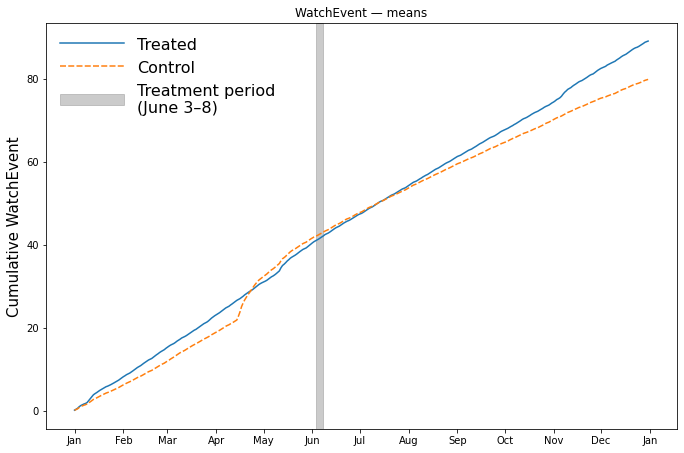

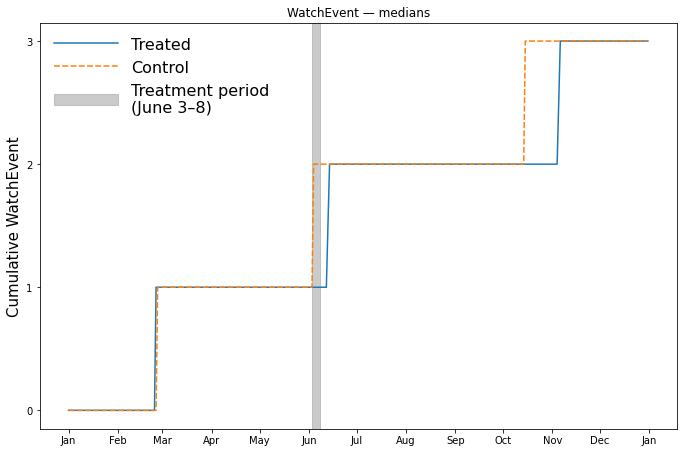

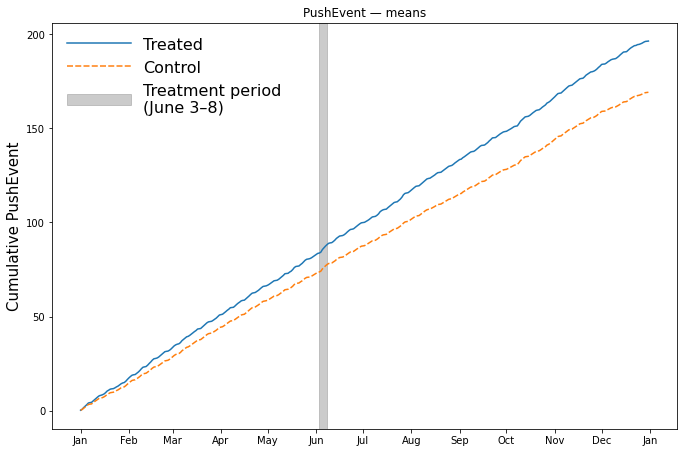

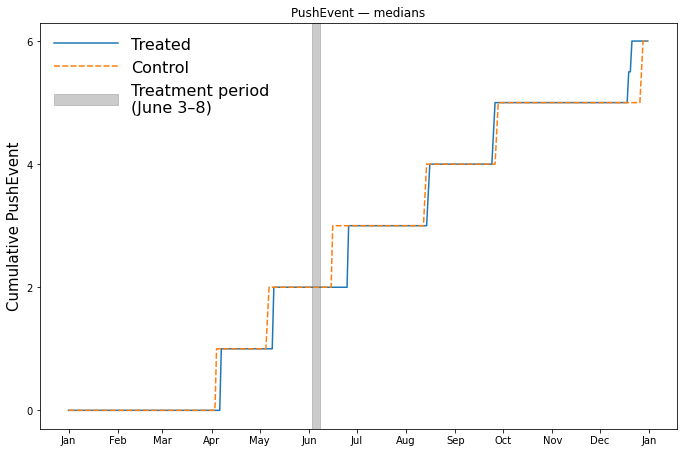

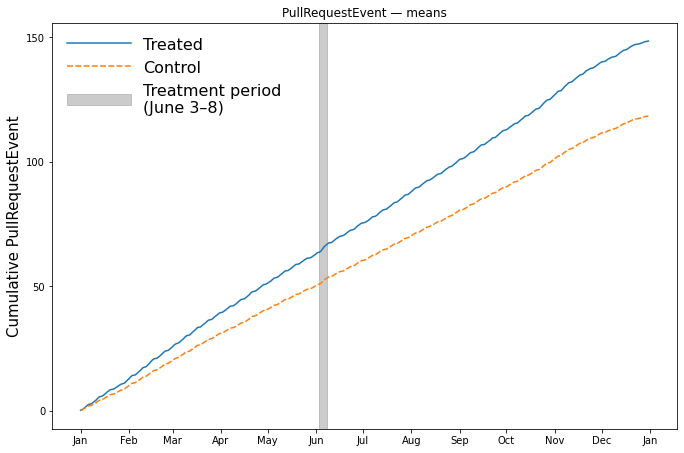

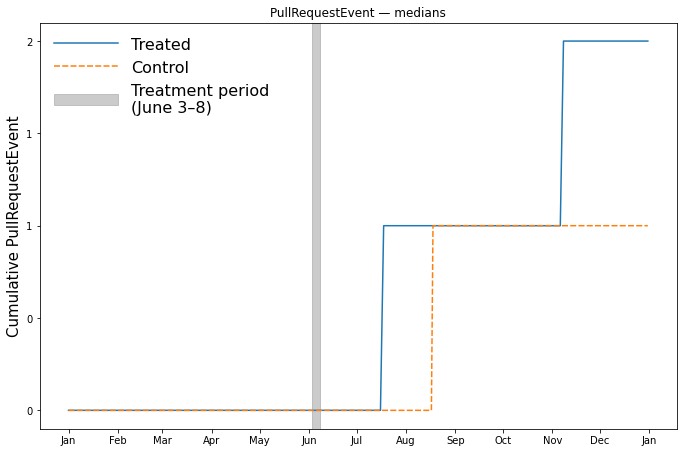

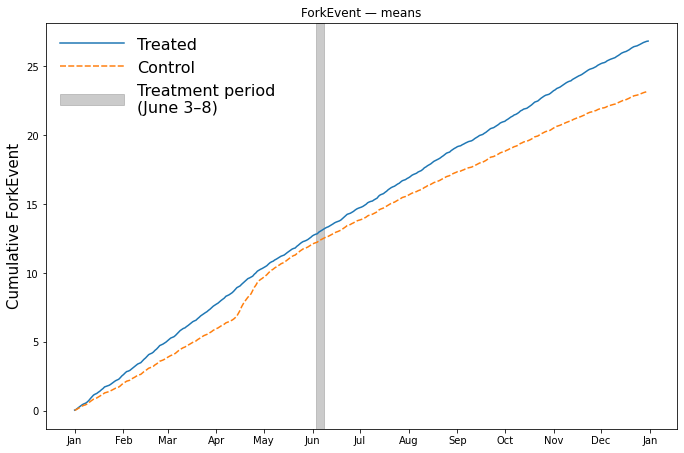

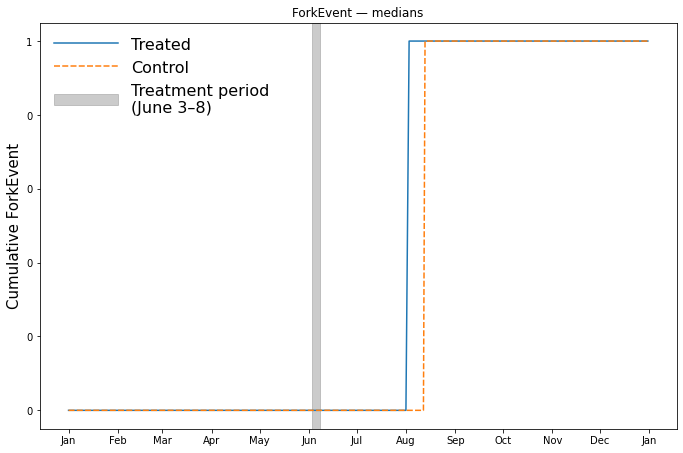

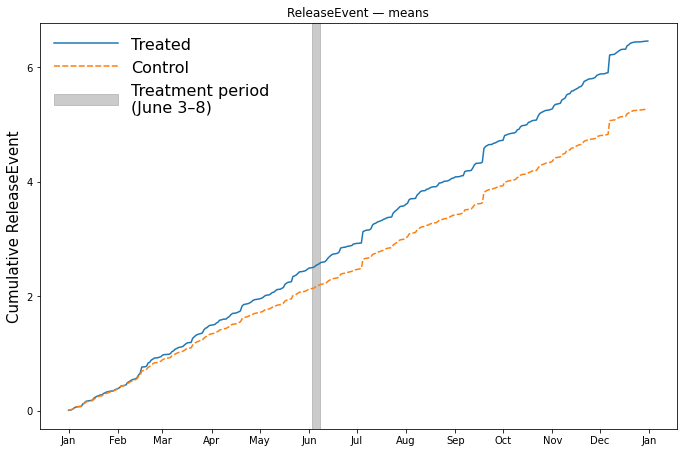

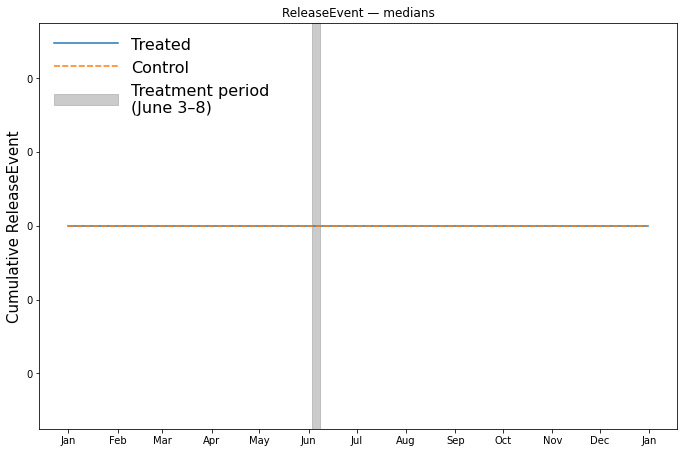

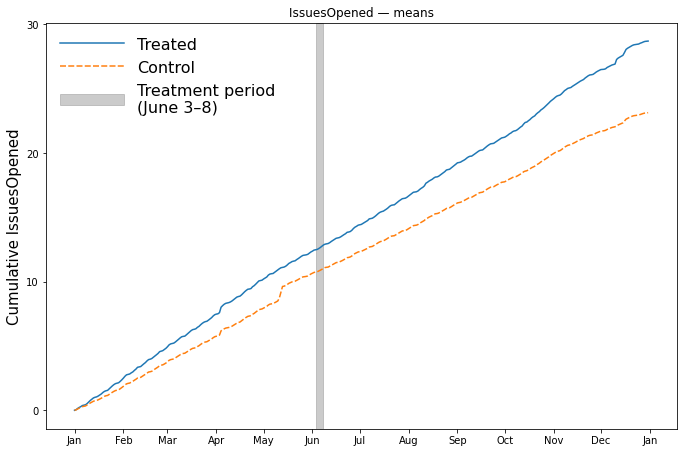

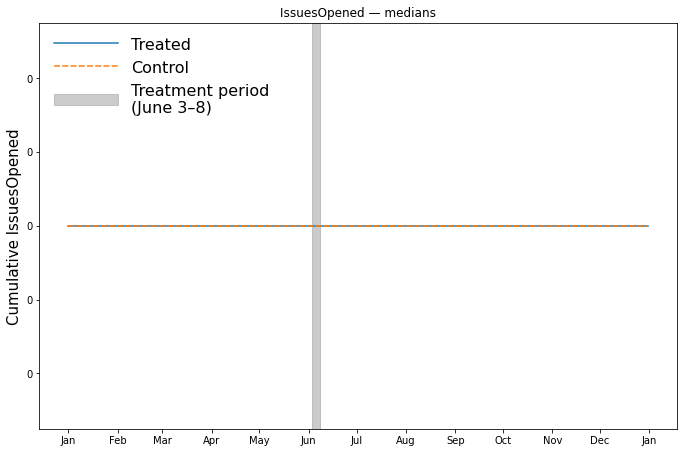

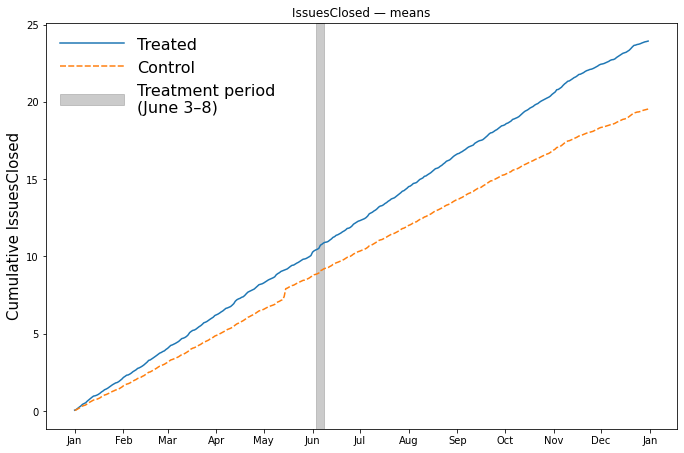

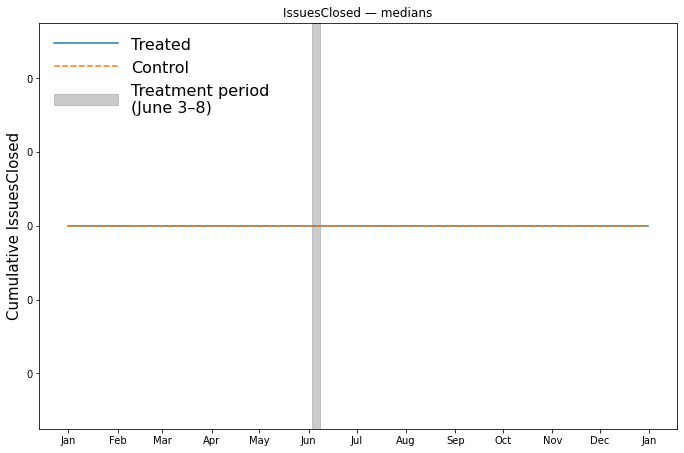

In [22]:
event_metrics = [
    "WatchEvent",
    "PushEvent",
    "PullRequestEvent",
    "ForkEvent",
    "ReleaseEvent",
    "IssuesOpened",
    "IssuesClosed",
]

for metric in event_metrics:
    for estimator, label in [("mean", "means"), (np.median, "medians")]:
        plot_treated_vs_control(
            df=df_daily,
            date_col="date",
            value_col=f"tt_{metric}",
            treatment_col="treatment",
            shade_start_date="2023-06-03",
            shade_end_date="2023-06-08",
            estimator=estimator,
            y_label=f"Cumulative {metric}",
            custom_labels=["Treated", "Control", "Treatment period\n(June 3–8)"],
        )
        ax = plt.gca()
        ax.xaxis.set_major_locator(mdates.MonthLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
        plt.title(f"{metric} — {label}")
        plt.tight_layout()
        plt.show()